In [159]:
# Data processing
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping

from keras import preprocessing as kprocessing
from keras import models, layers, optimizers

import gensim
import gensim.downloader as api

import matplotlib
from matplotlib import pyplot as plt

from datetime import datetime

In [68]:
df = pd.read_csv('tokopedia-cleaned.csv', low_memory=False)
replace_map = {
    1 :'negative',
    2 : 'positive',
    0 : 'neutral'  
}
df['sentiment'] = df['sentiment'].replace(replace_map)
df.rename(columns={"content": "text"}, inplace=True)
df = df[["sentiment", "text"]]
df.head()

,sentiment,text
0,positive,Tokped mantaap
1,negative,kurir pengiriman nya sangat mengecewakan ID ex...
2,negative,Pembatalan belanja status masih proses butuh w...
3,negative,satu fitur yang sangat disayangkan hilang tanp...
4,positive,toped mantab


In [70]:
category_counts = df.groupby('sentiment').size()

# Memfilter kategori yang memiliki lebih dari satu teks
df = df[df['sentiment'].isin(category_counts[category_counts > 1].index)]

print('Total number of news: {}'.format(len(df)))
print(40*'-')
print('Split by sentiment:')

print(df["sentiment"].value_counts())
print(40*'-')
nr_categories = len(df["sentiment"].unique())

print("Number of sentiment: {n}".format(n=nr_categories))

Total number of news: 993
----------------------------------------
Split by sentiment:
sentiment
negative    485
positive    424
neutral      84
Name: count, dtype: int64
----------------------------------------
Number of sentiment: 3


In [252]:
# Renaming, Input -> X, Output -> y
X_tf = df['text']
y_tf_class = df['sentiment']

# Convert labels into a one-hot vector of size 5 (the number of distinct labels)
lab = LabelBinarizer()
lab.fit(y_tf_class)
y_tf = lab.transform(y_tf_class)

# Example (you can modify n)
n=251
print('Coding of labels into a one-hot vector: ' + y_tf_class[n] + ' is ', y_tf[n])

# Split into training and test data
X_tf_train, X_tf_test, y_tf_train, y_tf_test = train_test_split(X_tf, y_tf, test_size=0.3, random_state=42, stratify=df['sentiment'])

Coding of labels into a one-hot vector: positive is  [0 0 1]


In [258]:
corpus = X_tf_train
max_words = 15000
tokenizer = kprocessing.text.Tokenizer(lower=True, split=' ', num_words=max_words, oov_token="<pad>", filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n')
tokenizer.fit_on_texts(corpus)
voc = tokenizer.word_index
reverse_voc = dict([(value, key) for (key, value) in voc.items()])

In [260]:
max_len = 200

sequences = tokenizer.texts_to_sequences(X_tf_train)
X_tf_train_seq = kprocessing.sequence.pad_sequences(sequences, maxlen=max_len)

# Apply the same to test data
X_tf_test_seq = kprocessing.sequence.pad_sequences(tokenizer.texts_to_sequences(X_tf_test), maxlen=max_len)

n=10 # You can adjust n
print('Shape: ',X_tf_train_seq.shape)
print(100*'-')
print('Example: ',X_tf_train_seq[n,:])

Shape:  (695, 200)
----------------------------------------------------------------------------------------------------
Example:  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0 566]


In [197]:
# SMOTE membutuhkan data dalam format 2D (tanpa padding)
# X_train_smote = X_tf_train_seq.reshape(X_tf_train_seq.shape[0], -1)
# y_train_smote = y_tf_train.argmax(axis=1)  # SMOTE bekerja dengan label non-one-hot

# # Oversampling dengan SMOTE
# smote = SMOTE(sampling_strategy='minority', random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X_train_smote, y_train_smote)

# # Kembalikan hasil resampling ke bentuk asli
# X_resampled = X_resampled.reshape(X_resampled.shape[0], max_len)
# y_resampled = np.eye(nr_categories)[y_resampled]  # Convert kembali ke one-hot encoding

# print("Distribusi setelah SMOTE:")
# print(pd.Series(y_resampled.argmax(axis=1)).value_counts())

Distribusi setelah SMOTE:
0    339
1    339
2    297
Name: count, dtype: int64


In [241]:
# This may take several minutes
w2v = api.load("word2vec-google-news-300")
# Example of a word representation:
w2v['hello'].shape

(300,)

In [268]:
# Build weights of the embbeddings matrix using w2v
# emb_matrix=np.zeros((max_words+1, 300))
# for i in range(max_words):
#     w = reverse_voc[i+1]
#     if w in w2v:
#         emb_matrix[i+1,:] = w2v[w]
# emb_size = emb_matrix.shape[1]

# Build weights of the embbeddings matrix using w2v
# emb_matrix=np.zeros((max_words+1, 300))
# for i in range(1,len(reverse_voc)+1):
#     w = reverse_voc.get(i)
#     if w in w2v:
#         emb_matrix[i,:] = w2v[w]
# emb_size = emb_matrix.shape[1]

emb_matrix = np.zeros((max_words+1, 300))
for i in range(max_words):
    if i+1 in reverse_voc:  # Pastikan indeks i+1 ada dalam reverse_voc
        w = reverse_voc[i+1]
        if w in w2v:
            emb_matrix[i+1, :] = w2v[w]
emb_size = emb_matrix.shape[1]

In [272]:
input_ = layers.Input(shape = X_tf_train_seq[0,:].shape,name='input')
# Embedding layer (voc size plus un ("UNK", word with index 0)), using the pre-trained emb_matrix obtained from Word2Vec
x = layers.Embedding(max_words+1,emb_size,weights=[emb_matrix],trainable=False, name='embedding')(input_)
x = layers.Bidirectional(layers.LSTM(15,dropout=0.2),name='bidirectional-lstm')(x) # LSTM layer
x = layers.Dropout(0.2, name='dropout')(x)
x = layers.Dense(64, activation='relu', name='dense')(x)
output = layers.Dense(nr_categories, activation='softmax', name='classification')(x)

model = models.Model(input_, output)

opt = optimizers.Adam(learning_rate=0.01, beta_1=0.9)
model.compile(optimizer=opt,loss='categorical_crossentropy', metrics=['accuracy'])

In [217]:
# class_weights = compute_class_weight(
#     class_weight='balanced', 
#     classes=np.unique(y_tf_train.argmax(axis=1)), 
#     y=y_tf_train.argmax(axis=1)
# )

# # Konversi class weight menjadi dictionary
# class_weights = dict(enumerate(class_weights))
# print("Class Weights:", class_weights)

Class Weights: {0: 0.6833824975417896, 1: 3.926553672316384, 2: 0.7800224466891134}


In [280]:
start_time = datetime.now()
history = model.fit(
    X_tf_train_seq, 
    y_tf_train, 
    batch_size=64, 
    shuffle=True, 
    epochs=15, 
    validation_data=(X_tf_test_seq, y_tf_test)
)

# early_stopping = EarlyStopping(
#     monitor='val_loss',
#     patience=3,  # Hentikan pelatihan jika val_loss tidak membaik dalam 3 epoch
#     restore_best_weights=True 
# )

# history = model.fit(
#     X_resampled, 
#     y_resampled, 
#     batch_size=64, 
#     shuffle=True, 
#     epochs=10, 
#     validation_data=(X_tf_test_seq, y_tf_test),
#     class_weight=class_weights,
#     callbacks=[early_stopping]
# )

end_time = datetime.now()

training_time_rnn = (end_time - start_time).total_seconds()

Epoch 1/15
11/11 [==============================] - 6s 532ms/step - loss: 0.3573 - accuracy: 0.8777 - val_loss: 0.6863 - val_accuracy: 0.7886
Epoch 2/15
11/11 [==============================] - 6s 536ms/step - loss: 0.3604 - accuracy: 0.8719 - val_loss: 0.7019 - val_accuracy: 0.7752
Epoch 3/15
11/11 [==============================] - 7s 625ms/step - loss: 0.3201 - accuracy: 0.9007 - val_loss: 0.7492 - val_accuracy: 0.8087
Epoch 4/15
11/11 [==============================] - 7s 622ms/step - loss: 0.3184 - accuracy: 0.8964 - val_loss: 0.8064 - val_accuracy: 0.8020
Epoch 5/15
11/11 [==============================] - 7s 611ms/step - loss: 0.2936 - accuracy: 0.9007 - val_loss: 0.7955 - val_accuracy: 0.7819
Epoch 6/15
11/11 [==============================] - 7s 620ms/step - loss: 0.2741 - accuracy: 0.9065 - val_loss: 0.9050 - val_accuracy: 0.7953
Epoch 7/15
11/11 [==============================] - 6s 573ms/step - loss: 0.2931 - accuracy: 0.9050 - val_loss: 0.7943 - val_accuracy: 0.7987
Epoch 

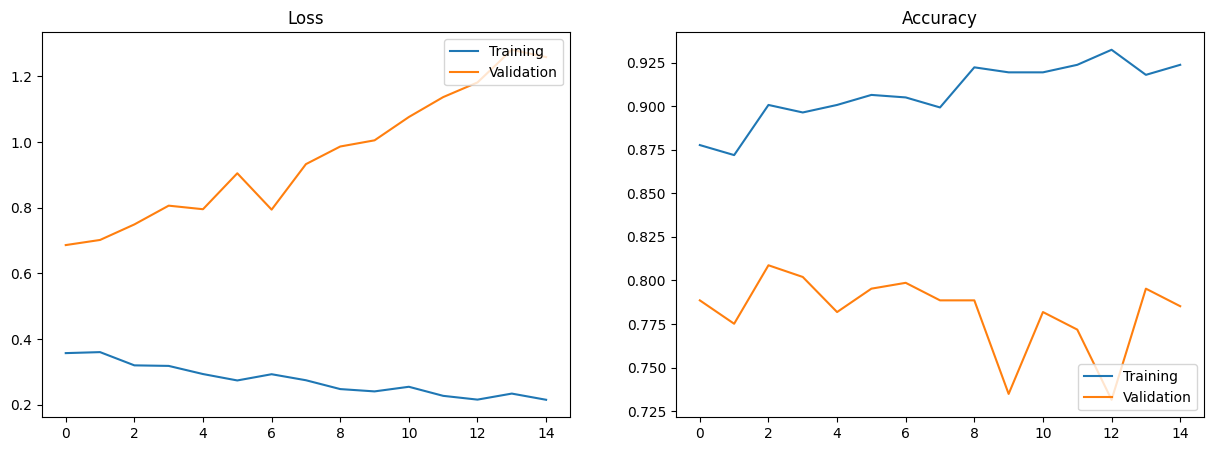

In [281]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
ax[0].set(title='Loss')
ax[0].plot(history.history['loss'], label='Training')
ax[0].plot(history.history['val_loss'], label='Validation')
ax[0].legend(loc="upper right")

ax[1].set(title='Accuracy')
ax[1].plot(history.history['accuracy'], label='Training')
ax[1].plot(history.history['val_accuracy'], label='Validation')
ax[1].legend(loc="lower right")

In [282]:
accuracy_rnn = history.history['val_accuracy'][-1]
print('Accuracy Training data: {:.1%}'.format(history.history['accuracy'][-1]))
print('Accuracy Test data: {:.1%}'.format(history.history['val_accuracy'][-1]))
print('Training time: {:.1f}s'.format(training_time_rnn))

Accuracy Training data: 92.4%
Accuracy Test data: 78.5%
Training time: 100.2s
